# Arabic Document Intelligence Platform
## SANAD Dataset — Multi-class Arabic Text Classification with AraBERT + LoRA Fine-tuning

**Pipeline:**
1. EDA & Feature Engineering on SANAD
2. Preprocessing & Tokenization
3. Base AraBERT evaluation (zero-shot)
4. LoRA Fine-tuning
5. Base vs Fine-tuned comparison
6. Gradio Web Demo
7. Export for AWS deployment

**Dataset:** SANAD — Saudi Arabic News Articles Dataset (7 categories)


## ─── Cell 1 · Install Dependencies ───

In [1]:
%%capture
!pip install transformers peft accelerate datasets evaluate gradio arabic-reshaper python-bidi pyarabic

In [2]:
!pip install arabic-reshaper python-bidi

## ─── Cell 2 · Imports & Configuration ───

In [3]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
from pathlib import Path
warnings.filterwarnings('ignore')

# Arabic text rendering
import arabic_reshaper
from bidi.algorithm import get_display

# ML / DL
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split
import evaluate

# ─── CONFIG ─────────────────────────────────────────────
CFG = {
    'model_name'       : 'aubmindlab/bert-base-arabertv02',
    'max_length'       : 256,
    'batch_size'       : 16,
    'num_epochs'       : 5,
    'learning_rate'    : 2e-5,
    'warmup_ratio'     : 0.1,
    'weight_decay'     : 0.01,
    'seed'             : 42,
    'output_dir'       : '/kaggle/working/',
    'lora_r'           : 16,
    'lora_alpha'       : 32,
    'lora_dropout'     : 0.1,
    'data_path'        : '/kaggle/input/datasets/haithemhermessi/sanad-dataset'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs(CFG['output_dir'], exist_ok=True)
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

print(f'\n Configuration set. Data path: {CFG["data_path"]}')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

 Configuration set. Data path: /kaggle/input/datasets/haithemhermessi/sanad-dataset


## ─── Cell 3 · Load SANAD Dataset ───

In [4]:
import pandas as pd
from pathlib import Path

SANAD_CATEGORIES = {
    'Culture'  : 'ثقافة',
    'Finance'  : 'مال وأعمال',
    'Medical'  : 'طب وصحة',
    'Politics' : 'سياسة',
    'Religion' : 'دين',
    'Sports'   : 'رياضة',
    'Tech'     : 'تكنولوجيا'
}

def load_sanad(data_path):
    """Load SANAD dataset where each category is a folder containing .txt files."""
    dfs = []
    path = Path(data_path)
    
    for cat_en, cat_ar in SANAD_CATEGORIES.items():
        cat_path = path / cat_en
        
        if not cat_path.exists():
            cat_path = path / cat_en.capitalize()
        if not cat_path.exists():
            cat_path = path / cat_en.lower()
            
        if cat_path.exists() and cat_path.is_dir():
            texts = []
            files = list(cat_path.glob('*.txt'))
            
            if not files:
                print(f'  Exist folder but not in .txt: {cat_en}')
                continue
                
            for f in files:
                try:
                    with open(f, 'r', encoding='utf-8') as file:
                        content = file.read().strip()
                        if content:  
                            texts.append(content)
                except Exception as e:
                    pass 
            
            if texts:
                df_tmp = pd.DataFrame({'text': texts})
                df_tmp['label_en'] = cat_en
                df_tmp['label_ar'] = cat_ar
                dfs.append(df_tmp)
                print(f'  Loaded {cat_ar}: {len(df_tmp):,} articles')
        else:
            print(f'   Folder not found for: {cat_en}')
    
    if not dfs:
        raise FileNotFoundError(f"Not found data in {data_path}. ")
    
    df = pd.concat(dfs, ignore_index=True)
    
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'id'}, inplace=True)
    
    return df

# ─── EXECUTION ──────────────────────────────────────────
print('\nLoading SANAD dataset...')
try:
    df = load_sanad(CFG['data_path'])

    label_list = sorted(df['label_en'].unique().tolist())
    label2id   = {l: i for i, l in enumerate(label_list)}
    id2label   = {i: l for l, i in label2id.items()}
    id2label_ar = {label2id[l]: SANAD_CATEGORIES[l] for l in label_list}

    df['label_id'] = df['label_en'].map(label2id)

    print(f'\nTotal articles: {len(df):,}')
    print(f'Categories: {len(label_list)}')
    print('\nLabel mapping:')
    for i, l in id2label.items():
        print(f'  {i}: {l} — {SANAD_CATEGORIES[l]}')
except Exception as e:
    print(f'\n Critical Error: {e}')


Loading SANAD dataset...
  Loaded ثقافة: 6,500 articles
  Loaded مال وأعمال: 6,500 articles
  Loaded طب وصحة: 6,500 articles
  Loaded سياسة: 6,500 articles
  Loaded دين: 6,500 articles
  Loaded رياضة: 6,500 articles
  Loaded تكنولوجيا: 6,500 articles

Total articles: 45,500
Categories: 7

Label mapping:
  0: Culture — ثقافة
  1: Finance — مال وأعمال
  2: Medical — طب وصحة
  3: Politics — سياسة
  4: Religion — دين
  5: Sports — رياضة
  6: Tech — تكنولوجيا


## ─── Cell 4 · Exploratory Data Analysis (EDA) ───

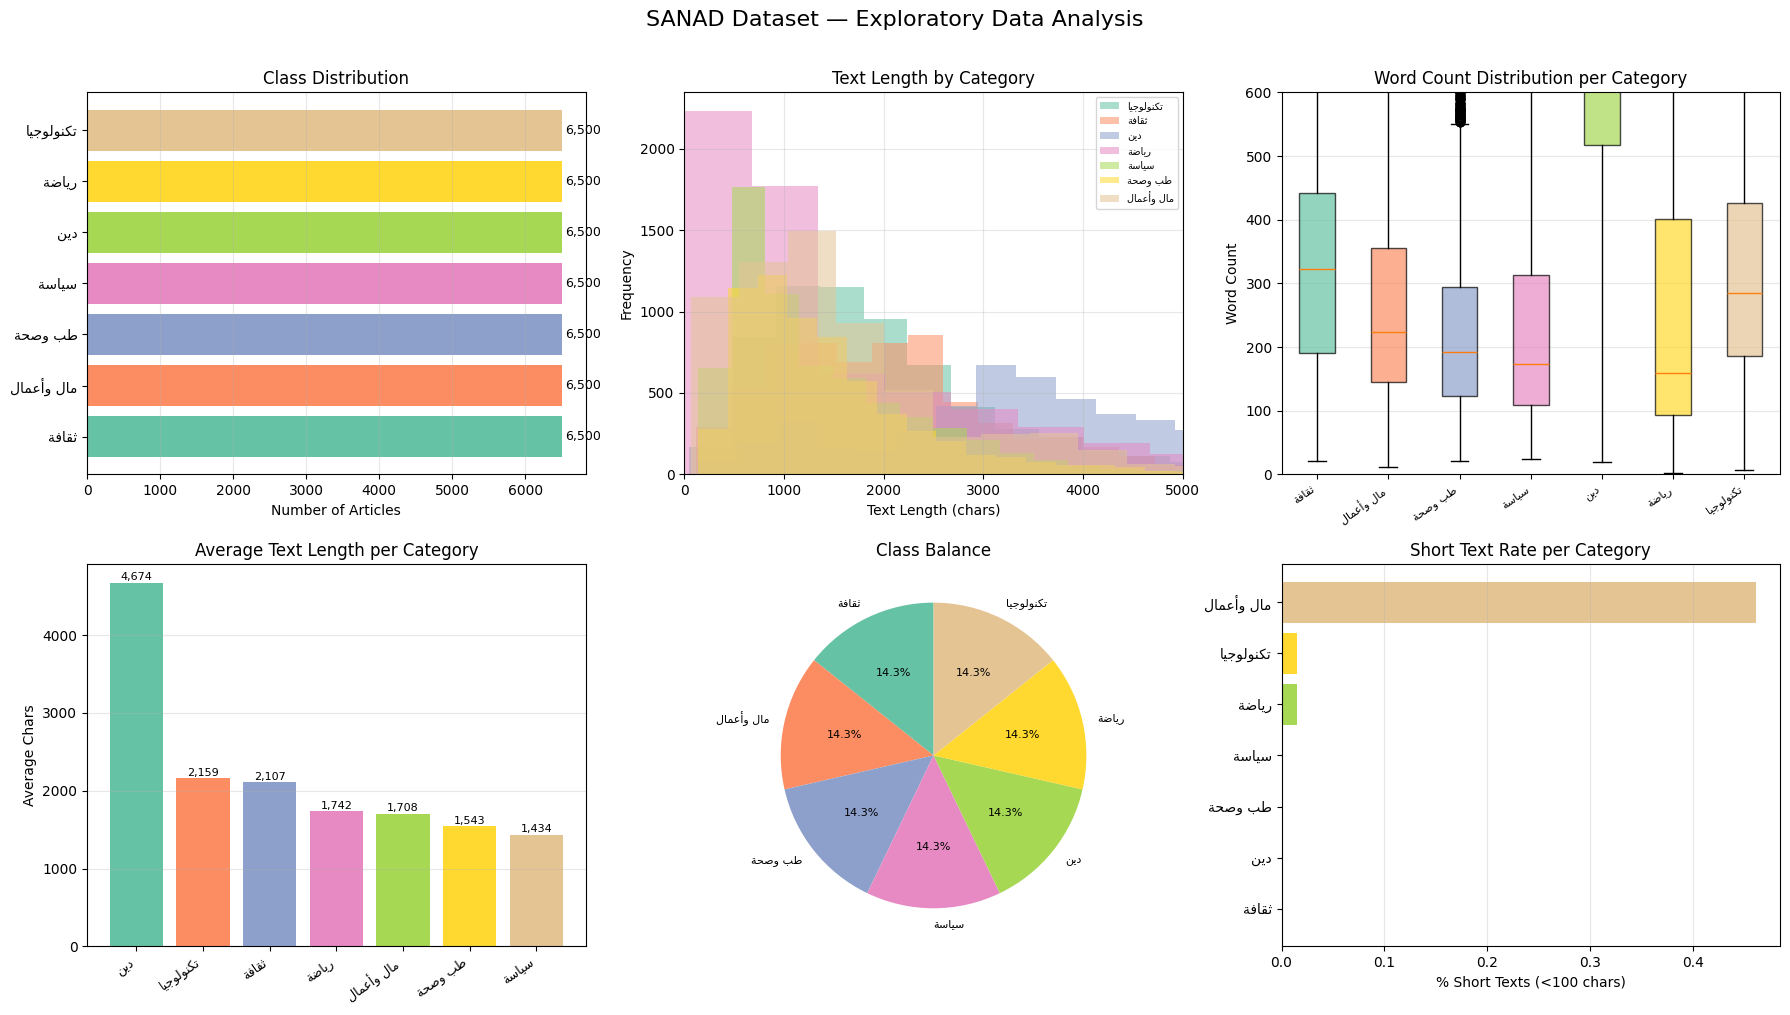

EDA plots saved.


In [5]:
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
def ar(text):
    """Reshape Arabic text for matplotlib rendering."""
    return get_display(arabic_reshaper.reshape(str(text)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SANAD Dataset — Exploratory Data Analysis', fontsize=16, y=1.01)
palette = sns.color_palette('Set2', 7)

# ── 1. Class Distribution ──────────────────────────────
ax = axes[0, 0]
cat_counts = df['label_ar'].value_counts()
bars = ax.barh(
    [ar(c) for c in cat_counts.index],
    cat_counts.values,
    color=palette
)
ax.set_xlabel('Number of Articles')
ax.set_title('Class Distribution')
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# ── 2. Text Length Distribution ───────────────────────
ax = axes[0, 1]
df['text_len'] = df['text'].str.len()
for i, (cat, grp) in enumerate(df.groupby('label_ar')):
    ax.hist(grp['text_len'], bins=50, alpha=0.55,
            label=ar(cat), color=palette[i])
ax.set_xlabel('Text Length (chars)')
ax.set_ylabel('Frequency')
ax.set_title('Text Length by Category')
ax.set_xlim(0, 5000)
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)

# ── 3. Word Count Distribution ───────────────────────
ax = axes[0, 2]
df['word_count'] = df['text'].str.split().str.len()
bp_data = [df[df['label_en'] == l]['word_count'].values for l in label_list]
bp = ax.boxplot(bp_data, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels([ar(SANAD_CATEGORIES[l]) for l in label_list],
                    rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Word Count')
ax.set_title('Word Count Distribution per Category')
ax.set_ylim(0, 600)
ax.grid(axis='y', alpha=0.3)

# ── 4. Average Text Length per Category ──────────────
ax = axes[1, 0]
avg_len = df.groupby('label_ar')['text_len'].mean().sort_values(ascending=False)
bars = ax.bar(
    [ar(c) for c in avg_len.index],
    avg_len.values,
    color=palette
)
ax.set_xticklabels([ar(c) for c in avg_len.index], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Average Chars')
ax.set_title('Average Text Length per Category')
for bar, val in zip(bars, avg_len.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(val):,}', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 5. Class Balance (Pie) ────────────────────────────
ax = axes[1, 1]
sizes = df['label_ar'].value_counts().values
labels_pie = [ar(l) for l in df['label_ar'].value_counts().index]
ax.pie(sizes, labels=labels_pie, colors=palette,
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 8})
ax.set_title('Class Balance')

# ── 6. Short Texts (<100 chars) per Category ─────────
ax = axes[1, 2]
short_pct = (df[df['text_len'] < 100]
             .groupby('label_ar').size() / df.groupby('label_ar').size() * 100)
short_pct = short_pct.fillna(0).sort_values(ascending=True)
ax.barh([ar(c) for c in short_pct.index], short_pct.values, color=palette[:len(short_pct)])
ax.set_xlabel('% Short Texts (<100 chars)')
ax.set_title('Short Text Rate per Category')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## ─── Cell 5 · Feature Engineering ───

Engineering features...

Feature statistics per category:


,char_count,word_count,unique_words,avg_word_len,lexical_density,sentence_count,avg_sent_len
label_ar,,,,,,,
تكنولوجيا,2160.00,350.64,233.38,6.16,0.71,28.94,12.51
ثقافة,2107.55,348.22,256.14,6.05,0.76,35.42,10.97
دين,4674.87,809.92,523.16,5.75,0.67,79.43,11.25
رياضة,1742.24,295.25,207.20,5.89,0.78,22.13,12.72
سياسة,1434.38,237.74,176.29,6.00,0.78,21.57,10.68
طب وصحة,1543.51,246.74,177.07,6.26,0.76,23.83,10.92
مال وأعمال,1708.21,296.18,175.00,5.72,0.66,45.05,7.92


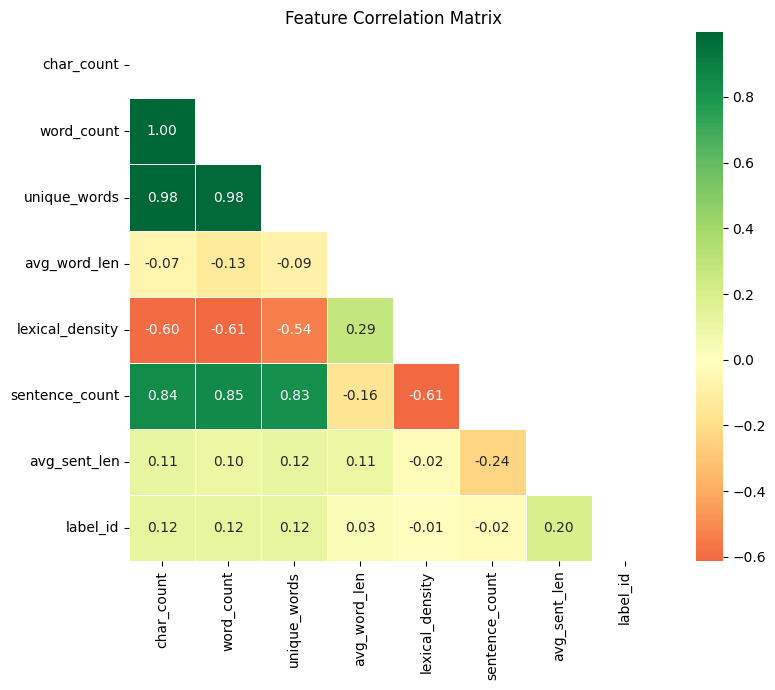


 Feature engineering complete.
Dataset shape: (45500, 19)


In [6]:
import pyarabic.araby as araby

def engineer_features(df):
    """Create textual + statistical features for analysis."""
    d = df.copy()
    
    # Basic stats
    d['char_count']      = d['text'].str.len()
    d['word_count']      = d['text'].str.split().str.len()
    d['unique_words']    = d['text'].apply(lambda x: len(set(str(x).split())))
    d['avg_word_len']    = d['char_count'] / (d['word_count'] + 1)
    d['lexical_density'] = d['unique_words'] / (d['word_count'] + 1)
    
    # Arabic-specific
    d['has_diacritics']  = d['text'].str.contains('[\u064b-\u065f]', regex=True)
    d['has_numbers']     = d['text'].str.contains('[0-9٠-٩]', regex=True)
    d['has_foreign']     = d['text'].str.contains('[a-zA-Z]', regex=True)
    d['exclamation_ct']  = d['text'].str.count('!')
    d['question_ct']     = d['text'].str.count('؟|\?')
    
    # Sentence count (Arabic sentence boundary)
    d['sentence_count']  = d['text'].str.count('[.!؟،]') + 1
    d['avg_sent_len']    = d['word_count'] / (d['sentence_count'] + 1)
    
    # Stem ratio (how many words can be stemmed — proxy for formal writing)
    def stem_ratio(text):
        words = str(text).split()[:50]  # sample first 50 words for speed
        stemmed = [araby.strip_tatweel(araby.strip_diacritics(w)) for w in words]
        changed = sum(1 for a, b in zip(words, stemmed) if a != b)
        return changed / max(len(words), 1)
    
    d['stem_ratio'] = d['text'].apply(stem_ratio)
    
    return d


print('Engineering features...')
df = engineer_features(df)

# ── Feature summary stats
feat_cols = ['char_count','word_count','unique_words','avg_word_len',
             'lexical_density','sentence_count','avg_sent_len']
print('\nFeature statistics per category:')
display(df.groupby('label_ar')[feat_cols].mean().round(2))

# ── Correlation heatmap
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
numeric_feat = df[feat_cols + ['label_id']]
corr = numeric_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/feature_correlation.png", dpi=150)
plt.show()

print('\n Feature engineering complete.')
print(f'Dataset shape: {df.shape}')

## ─── Cell 6 · Arabic Text Preprocessing ───

In [7]:
import pyarabic.araby as araby

class ArabicTextCleaner:
    """Comprehensive Arabic text preprocessing pipeline."""
    
    ARABIC_PUNCTUATION = '،؛؟·'
    
    def __init__(self, 
                 remove_diacritics=True,
                 normalize_alef=True,
                 normalize_teh_marbuta=True,
                 remove_tatweel=True,
                 remove_html=True,
                 remove_urls=True,
                 remove_emails=True,
                 remove_extra_spaces=True,
                 max_length=None):
        
        self.remove_diacritics     = remove_diacritics
        self.normalize_alef        = normalize_alef
        self.normalize_teh_marbuta = normalize_teh_marbuta
        self.remove_tatweel        = remove_tatweel
        self.remove_html           = remove_html
        self.remove_urls           = remove_urls
        self.remove_emails         = remove_emails
        self.remove_extra_spaces   = remove_extra_spaces
        self.max_length            = max_length
    
    def clean(self, text: str) -> str:
        if not isinstance(text, str):
            text = str(text)
        
        if self.remove_html:
            text = re.sub(r'<[^>]+>', ' ', text)
        
        if self.remove_urls:
            text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
        
        if self.remove_emails:
            text = re.sub(r'\S+@\S+\.\S+', ' ', text)
        
        # Remove non-Arabic, non-space, keep Arabic punctuation
        text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\s\.!?؟،؛]', ' ', text)
        
        if self.remove_diacritics:
            text = araby.strip_diacritics(text)
        
        if self.normalize_alef:
            text = araby.normalize_alef(text)
        
        if self.normalize_teh_marbuta:
            text = araby.normalize_teh(text)
        
        if self.remove_tatweel:
            text = araby.strip_tatweel(text)
        
        if self.remove_extra_spaces:
            text = re.sub(r'\s+', ' ', text).strip()
        
        if self.max_length:
            text = text[:self.max_length]
        
        return text
    
    def __call__(self, text: str) -> str:
        return self.clean(text)


# Instantiate cleaner
cleaner = ArabicTextCleaner()


# Apply to full dataset
print('\nCleaning dataset...')
df['text_clean'] = df['text'].apply(cleaner)

# Drop empty after cleaning
before = len(df)
df = df[df['text_clean'].str.len() >= 20].reset_index(drop=True)
after = len(df)
print(f'Removed {before - after} very short texts.')
print(f'Final dataset size: {after:,} articles')
print('\nPreprocessing complete.')


Cleaning dataset...
Removed 1 very short texts.
Final dataset size: 45,499 articles

Preprocessing complete.


## ─── Cell 7 · Train / Val / Test Split ───

In [8]:
# Stratified 80/10/10 split
train_df, temp_df = train_test_split(
    df[['text_clean', 'label_id', 'label_en', 'label_ar']],
    test_size=0.20,
    stratify=df['label_id'],
    random_state=CFG['seed']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_id'],
    random_state=CFG['seed']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('Split summary:')
print(f'  Train : {len(train_df):>7,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'  Val   : {len(val_df):>7,}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'  Test  : {len(test_df):>7,}  ({len(test_df)/len(df)*100:.1f}%)')

# Verify stratification
print('\nClass distribution in splits:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split['label_en'].value_counts(normalize=True).round(3) * 100
    print(f'  {name}: {dict(dist)}')

print('\n Data splits ready.')

Split summary:
  Train :  36,399  (80.0%)
  Val   :   4,550  (10.0%)
  Test  :   4,550  (10.0%)

Class distribution in splits:
  Train: {'Politics': np.float64(14.299999999999999), 'Culture': np.float64(14.299999999999999), 'Tech': np.float64(14.299999999999999), 'Medical': np.float64(14.299999999999999), 'Finance': np.float64(14.299999999999999), 'Religion': np.float64(14.299999999999999), 'Sports': np.float64(14.299999999999999)}
  Val: {'Medical': np.float64(14.299999999999999), 'Finance': np.float64(14.299999999999999), 'Religion': np.float64(14.299999999999999), 'Politics': np.float64(14.299999999999999), 'Tech': np.float64(14.299999999999999), 'Culture': np.float64(14.299999999999999), 'Sports': np.float64(14.299999999999999)}
  Test: {'Sports': np.float64(14.299999999999999), 'Religion': np.float64(14.299999999999999), 'Tech': np.float64(14.299999999999999), 'Culture': np.float64(14.299999999999999), 'Politics': np.float64(14.299999999999999), 'Medical': np.float64(14.2999999999

## ─── Cell 8 · Tokenizer & Dataset Class ───

In [9]:
print(f"Loading tokenizer: {CFG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])


class SANADDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text  = str(self.data.loc[idx, 'text_clean'])
        label = int(self.data.loc[idx, 'label_id'])
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels'        : torch.tensor(label, dtype=torch.long)
        }


train_dataset = SANADDataset(train_df, tokenizer, CFG['max_length'])
val_dataset   = SANADDataset(val_df,   tokenizer, CFG['max_length'])
test_dataset  = SANADDataset(test_df,  tokenizer, CFG['max_length'])

print(f'\nDataset sizes:')
print(f'  Train: {len(train_dataset):,}')
print(f'  Val  : {len(val_dataset):,}')
print(f'  Test : {len(test_dataset):,}')

# Inspect a sample
sample = train_dataset[0]
print(f'\nSample input_ids shape : {sample["input_ids"].shape}')
print(f'Sample attention_mask  : {sample["attention_mask"].sum().item()} non-pad tokens')
print(f'Sample label           : {sample["labels"].item()} ({id2label_ar[sample["labels"].item()]})')
print('\n Datasets ready.')

Loading tokenizer: aubmindlab/bert-base-arabertv02


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Dataset sizes:
  Train: 36,399
  Val  : 4,550
  Test : 4,550

Sample input_ids shape : torch.Size([256])
Sample attention_mask  : 185 non-pad tokens
Sample label           : 3 (سياسة)

 Datasets ready.


Running 5-Fold Cross Validation...

Fold 1/5


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.289629,0.226343,0.974176,0.974164
2,0.194670,0.181932,0.976044,0.976029


...

  Fold 4 — Accuracy: 0.9702 | F1: 0.9702

Fold 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.362936,0.305097,0.962413,0.962347
2,0.230449,0.236245,0.965820,0.965755


  Fold 5 — Accuracy: 0.9658 | F1: 0.9658

Cross Validation Results (5-Fold):
  Mean Accuracy : 0.9711 ± 0.0033
  Mean F1 Score : 0.9711 ± 0.0033
  Per-Fold Acc  : [0.976, 0.9724, 0.9711, 0.9702, 0.9658]


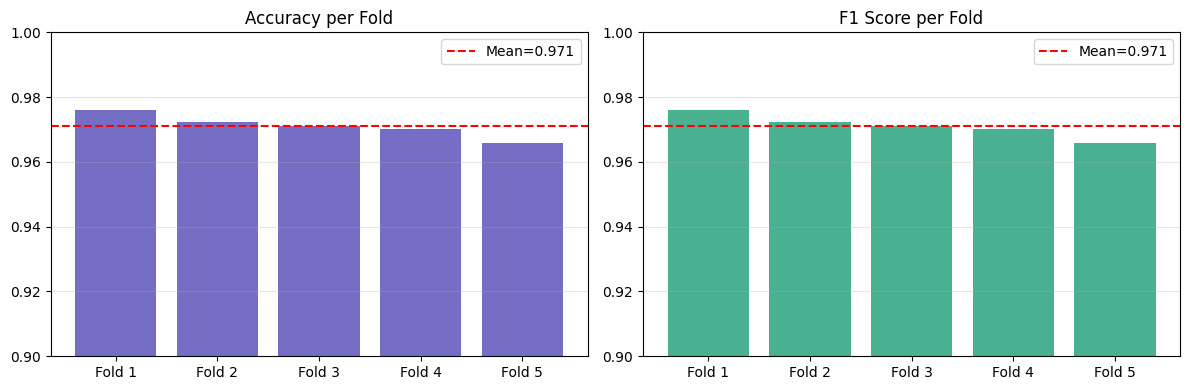

 Cross Validation done


In [10]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1'      : f1_score(labels, preds, average='weighted')
    }

# ── Cross Validation with Stratified K-Fold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("Running 5-Fold Cross Validation...")
print("="*50)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG['seed'])

X = df['text_clean'].values
y = df['label_id'].values

cv_accuracies = []
cv_f1_scores  = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/5")
    
    fold_train = df.iloc[train_idx][['text_clean','label_id']].reset_index(drop=True)
    fold_val   = df.iloc[val_idx][['text_clean','label_id']].reset_index(drop=True)
    
    fold_train_dataset = SANADDataset(fold_train, tokenizer, CFG['max_length'])
    fold_val_dataset   = SANADDataset(fold_val,   tokenizer, CFG['max_length'])
    
    # Load fresh model for each fold
    fold_model = AutoModelForSequenceClassification.from_pretrained(
        CFG['model_name'], num_labels=len(label_list)
    )
    fold_model = get_peft_model(fold_model, LoraConfig(
        task_type=TaskType.SEQ_CLS, r=CFG['lora_r'],
        lora_alpha=CFG['lora_alpha'], lora_dropout=CFG['lora_dropout'],
        bias='none', target_modules=['query','value'], inference_mode=False
    ))
    
    fold_args = TrainingArguments(
        output_dir=f"{CFG['output_dir']}/fold_{fold+1}",
        num_train_epochs=2,
        per_device_train_batch_size=CFG['batch_size'],
        per_device_eval_batch_size=CFG['batch_size']*2,
        learning_rate=CFG['learning_rate'],
        eval_strategy='epoch',
        save_strategy='no',
        fp16=torch.cuda.is_available(),
        report_to='none',
        logging_steps=100,
    )
    
    fold_trainer = Trainer(
    model=fold_model,
    args=fold_args,
    train_dataset=fold_train_dataset,
    eval_dataset=fold_val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
    
    fold_trainer.train()
    
    # Evaluate
    fold_model.to(device)
    fold_model.eval()
    loader = DataLoader(fold_val_dataset, batch_size=32, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            preds = fold_model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            ).logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())
    
    fold_acc = accuracy_score(all_labels, all_preds)
    fold_f1  = f1_score(all_labels, all_preds, average='weighted')
    cv_accuracies.append(fold_acc)
    cv_f1_scores.append(fold_f1)
    print(f"  Fold {fold+1} — Accuracy: {fold_acc:.4f} | F1: {fold_f1:.4f}")

print("\n" + "="*50)
print(f"Cross Validation Results (5-Fold):")
print(f"  Mean Accuracy : {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"  Mean F1 Score : {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"  Per-Fold Acc  : {[round(a,4) for a in cv_accuracies]}")
print("="*50)

# Plot CV results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
folds = [f'Fold {i+1}' for i in range(5)]

axes[0].bar(folds, cv_accuracies, color='#534AB7', alpha=0.8)
axes[0].axhline(np.mean(cv_accuracies), color='red', linestyle='--', label=f'Mean={np.mean(cv_accuracies):.3f}')
axes[0].set_title('Accuracy per Fold')
axes[0].set_ylim(0.9, 1.0)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(folds, cv_f1_scores, color='#1D9E75', alpha=0.8)
axes[1].axhline(np.mean(cv_f1_scores), color='red', linestyle='--', label=f'Mean={np.mean(cv_f1_scores):.3f}')
axes[1].set_title('F1 Score per Fold')
axes[1].set_ylim(0.9, 1.0)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/cross_validation.png", dpi=150)
plt.show()
print(' Cross Validation done')

## ─── Cell 9 · Base Model Evaluation (Zero-Shot Baseline) ───

In [11]:
print('Loading base AraBERT model (no fine-tuning)...')

base_model = AutoModelForSequenceClassification.from_pretrained(
    CFG['model_name'],
    num_labels=len(label_list),
    id2label=id2label_ar,
    label2id={v: k for k, v in id2label_ar.items()}
).to(device)

def evaluate_model(model, dataset, batch_size=32, desc='Evaluating'):
    """Run inference and return predictions + true labels."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].numpy()
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds   = probs.argmax(axis=-1)
            
            all_preds.extend(preds)
            all_labels.extend(labels)
            all_probs.extend(probs)
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


print('\nRunning base model on test set (this may take a few minutes)...')
base_preds, true_labels, base_probs = evaluate_model(base_model, test_dataset)

base_acc = accuracy_score(true_labels, base_preds)
base_f1  = f1_score(true_labels, base_preds, average='weighted')

print(f'\n── Base Model Results (untrained classifier head) ──')
print(f'  Accuracy (weighted) : {base_acc:.4f}')
print(f'  F1 Score (weighted) : {base_f1:.4f}')
print('\nNote: Low scores expected — classifier head is randomly initialized.')
print('\n Baseline evaluation complete.')

Loading base AraBERT model (no fine-tuning)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside


Running base model on test set (this may take a few minutes)...

── Base Model Results (untrained classifier head) ──
  Accuracy (weighted) : 0.1374
  F1 Score (weighted) : 0.1043

Note: Low scores expected — classifier head is randomly initialized.

 Baseline evaluation complete.


## ─── Cell 10 · LoRA Configuration & Fine-tuning ───

In [12]:
import time
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score
import evaluate

print('Setting up LoRA fine-tuning...')

num_labels = len(label_list)
id2label_map = {i: SANAD_CATEGORIES[l] for i, l in enumerate(label_list)}
label2id_map = {v: k for k, v in id2label_map.items()}

# Fresh model
ft_model = AutoModelForSequenceClassification.from_pretrained(
    CFG['model_name'],
    num_labels=num_labels,
    id2label=id2label_map,
    label2id=label2id_map
).to(device)

# LoRA config — target query and value projection matrices in BERT
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=CFG['lora_r'],
    lora_alpha=CFG['lora_alpha'],
    lora_dropout=CFG['lora_dropout'],
    bias='none',
    target_modules=['query', 'value'],  # BERT attention modules
    inference_mode=False
)

ft_model = get_peft_model(ft_model, lora_config)

ft_model.print_trainable_parameters()
# ────────────────────────────────────────────────────────

print('\nLoRA configuration:')
print(f'  r (rank)      : {CFG["lora_r"]}')
print(f'  alpha         : {CFG["lora_alpha"]}')
print(f'  dropout       : {CFG["lora_dropout"]}')
print(f'  target modules: query, value')


# ── Metrics ────────────────────────────────────────────
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}


# ── Training Arguments ─────────────────────────────────
training_args = TrainingArguments(
    output_dir=CFG['output_dir'],
    num_train_epochs=CFG['num_epochs'],
    per_device_train_batch_size=CFG['batch_size'],
    per_device_eval_batch_size=CFG['batch_size'] * 2,
    learning_rate=CFG['learning_rate'],
    # warmup_ratio=CFG['warmup_ratio'],
    weight_decay=CFG['weight_decay'],
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=CFG['seed'],
    dataloader_num_workers=2
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('\nStarting training...')
start = time.time()
trainer.train()
elapsed = time.time() - start
print(f'\nTraining completed in {elapsed/60:.1f} minutes.')

# Save fine-tuned model
ft_save_path = f"{CFG['output_dir']}/lora-finetuned"
trainer.save_model(ft_save_path)
tokenizer.save_pretrained(ft_save_path)

print(f' Model saved to {ft_save_path}')

Setting up LoRA fine-tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

trainable params: 595,207 || all params: 135,793,934 || trainable%: 0.4383

LoRA configuration:
  r (rank)      : 16
  alpha         : 32
  dropout       : 0.1
  target modules: query, value



Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.270686,0.217054,0.968352,0.968205
2,0.175159,0.148255,0.977582,0.977549
3,0.141209,0.135626,0.978462,0.978419
4,0.167256,0.133066,0.979341,0.979294
5,0.146790,0.130507,0.980000,0.979964



Training completed in 72.0 minutes.
 Model saved to /kaggle/working//lora-finetuned


## ─── Cell 11 · Base vs Fine-tuned Comparison ───

Evaluating fine-tuned model on test set...

  Model                       Accuracy     F1 (w)
-------------------------------------------------------
  Base AraBERT                  0.1374     0.1043
  LoRA Fine-tuned               0.9787     0.9787
  Improvement ↑                +0.8413    +0.8743

Fine-tuned Model — Classification Report:
              precision    recall  f1-score   support

       ثقافة     0.9500    0.9646    0.9573       650
  مال وأعمال     0.9847    0.9908    0.9877       650
     طب وصحة     0.9772    0.9877    0.9824       650
       سياسة     0.9863    0.9938    0.9900       650
         دين     0.9716    0.9462    0.9587       650
       رياضة     0.9985    0.9969    0.9977       650
   تكنولوجيا     0.9829    0.9708    0.9768       650

    accuracy                         0.9787      4550
   macro avg     0.9787    0.9787    0.9787      4550
weighted avg     0.9787    0.9787    0.9787      4550



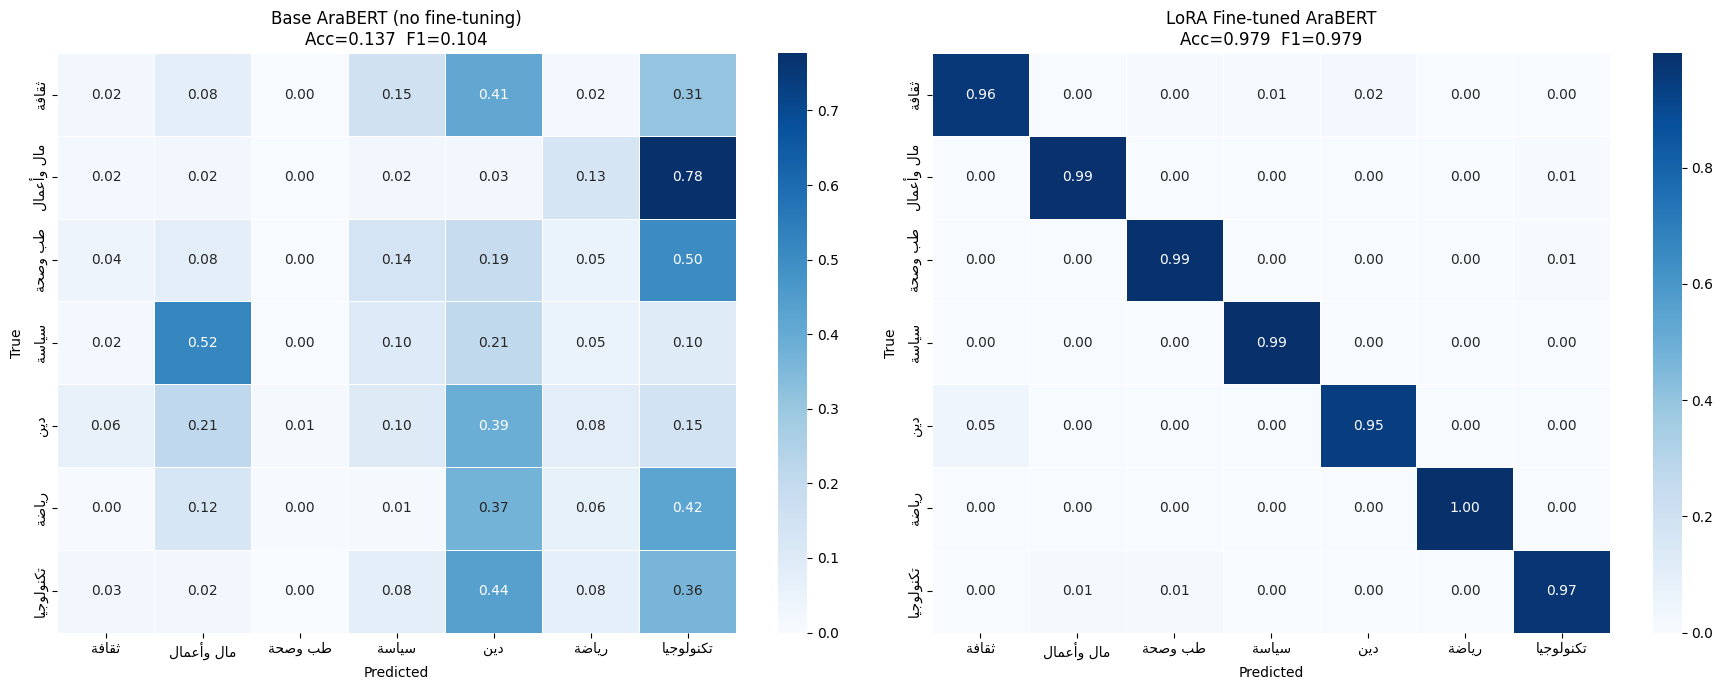


 Comparison complete. Metrics saved.


In [13]:
print('Evaluating fine-tuned model on test set...')
ft_preds, true_labels, ft_probs = evaluate_model(ft_model, test_dataset)

ft_acc = accuracy_score(true_labels, ft_preds)
ft_f1  = f1_score(true_labels, ft_preds, average='weighted')

print('\n' + '='*55)
print(f'  {'Model':<25} {'Accuracy':>10} {'F1 (w)':>10}')
print('-'*55)
print(f'  {"Base AraBERT":<25} {base_acc:>10.4f} {base_f1:>10.4f}')
print(f'  {"LoRA Fine-tuned":<25} {ft_acc:>10.4f} {ft_f1:>10.4f}')
print(f'  {"Improvement ↑":<25} {(ft_acc-base_acc):>+10.4f} {(ft_f1-base_f1):>+10.4f}')
print('='*55)

# ── Detailed Classification Report
cat_names = [SANAD_CATEGORIES[id2label[i]] for i in range(len(label_list))]
print('\nFine-tuned Model — Classification Report:')
print(classification_report(true_labels, ft_preds,
                             target_names=cat_names,
                             digits=4))

# ── Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, title in [
    (axes[0], base_preds, 'Base AraBERT (no fine-tuning)'),
    (axes[1], ft_preds,   'LoRA Fine-tuned AraBERT')
]:
    cm = confusion_matrix(true_labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[ar(c) for c in cat_names],
                yticklabels=[ar(c) for c in cat_names],
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nAcc={accuracy_score(true_labels, preds):.3f}  F1={f1_score(true_labels, preds, average="weighted"):.3f}')

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/confusion_matrix_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save metrics JSON
metrics = {
    'base': {'accuracy': float(base_acc), 'f1_weighted': float(base_f1)},
    'finetuned': {'accuracy': float(ft_acc), 'f1_weighted': float(ft_f1)},
    'improvement': {'accuracy': float(ft_acc - base_acc), 'f1_weighted': float(ft_f1 - base_f1)}
}
with open(f"{CFG['output_dir']}/metrics_comparison.json", 'w') as f:
    json.dump(metrics, f, indent=2)

print('\n Comparison complete. Metrics saved.')

## ─── Cell 12 · Inference Helper & Structured Output ───

In [14]:
class ArabicDocumentClassifier:
    """Production-ready inference wrapper with structured output."""
    
    SUBCATEGORIES = {
        'sports'       : ['كرة القدم','التنس','السباحة','ألعاب القوى','رياضات قتالية'],
        'economy'      : ['أسواق مالية','نفط وطاقة','عقارات','تجارة دولية','بنوك'],
        'science'      : ['ذكاء اصطناعي','فضاء','طب','بيئة','فيزياء'],
        'culture'      : ['سينما','موسيقى','أدب','تراث','مسرح'],
        'local_news'   : ['حكومة','بنية تحتية','مجتمع','تعليم','صحة عامة'],
        'international': ['شرق أوسط','أوروبا','أمريكا','آسيا','إفريقيا'],
        'religion'     : ['إسلام','فتاوى','مناسبات دينية','تعليم ديني','قيم']
    }
    
    def __init__(self, model, tokenizer, label_list, id2label, id2label_ar,
                 cleaner, device, max_length=256):
        self.model      = model
        self.tokenizer  = tokenizer
        self.label_list = label_list
        self.id2label   = id2label
        self.id2label_ar = id2label_ar
        self.cleaner    = cleaner
        self.device     = device
        self.max_length = max_length
        self.model.eval()
    
    def predict(self, text: str) -> dict:
        cleaned = self.cleaner(text)
        
        enc = self.tokenizer(
            cleaned,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        with torch.no_grad():
            input_ids  = enc['input_ids'].to(self.device)
            att_mask   = enc['attention_mask'].to(self.device)
            logits     = self.model(input_ids=input_ids, attention_mask=att_mask).logits
            probs      = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        
        top_idx   = probs.argmax()
        label_en  = self.id2label[top_idx]
        
        # All category probabilities sorted
        sorted_probs = sorted(
            [(self.id2label_ar[i], self.id2label[i], float(probs[i]))
             for i in range(len(probs))],
            key=lambda x: -x[2]
        )
        
        return {
            'input_text'         : text[:200] + '...' if len(text) > 200 else text,
            'cleaned_text'       : cleaned[:200] + '...' if len(cleaned) > 200 else cleaned,
            'predicted_label_en' : label_en,
            'predicted_label_ar' : self.id2label_ar[top_idx],
            'confidence'         : float(probs[top_idx]),
            'subcategories'      : self.SUBCATEGORIES.get(label_en, []),
            'all_probabilities'  : [
                {'label_ar': ar_lbl, 'label_en': en_lbl, 'probability': prob}
                for ar_lbl, en_lbl, prob in sorted_probs
            ]
        }
    
    def predict_batch(self, texts: list) -> list:
        return [self.predict(t) for t in texts]


# Instantiate
classifier = ArabicDocumentClassifier(
    model=ft_model,
    tokenizer=tokenizer,
    label_list=label_list,
    id2label=id2label,
    id2label_ar=id2label_ar,
    cleaner=cleaner,
    device=device
)

# ── Test with examples ─────────────────────────────────
test_texts = [
    'سجل الفريق الوطني ثلاثة أهداف في المباراة النهائية لكأس الخليج وتأهل للدور القادم',
    'ارتفعت أسعار النفط الخام إلى أعلى مستوياتها منذ ستة أشهر وسط توترات في المنطقة',
    'أعلنت الحكومة عن حزمة إصلاحات اقتصادية شاملة تستهدف خفض معدلات البطالة',
    'كشف العلماء عن اكتشاف نوع جديد من المضادات الحيوية يقاوم البكتيريا المقاومة',
]

print('── Inference Examples ──\n')
for txt in test_texts:
    result = classifier.predict(txt)
    top3 = result['all_probabilities'][:3]
    print(f"Text    : {txt[:70]}...")
    print(f"Category: {result['predicted_label_ar']} ({result['predicted_label_en']})")
    print(f"Conf    : {result['confidence']:.3f}")
    print(f"Top-3   : {[(p['label_ar'], round(p['probability'],3)) for p in top3]}")
    print()

print('Inference wrapper ready.')

── Inference Examples ──

Text    : سجل الفريق الوطني ثلاثة أهداف في المباراة النهائية لكأس الخليج وتأهل ل...
Category: رياضة (Sports)
Conf    : 0.961
Top-3   : [('رياضة', 0.961), ('سياسة', 0.015), ('دين', 0.009)]

Text    : ارتفعت أسعار النفط الخام إلى أعلى مستوياتها منذ ستة أشهر وسط توترات في...
Category: مال وأعمال (Finance)
Conf    : 0.708
Top-3   : [('مال وأعمال', 0.708), ('سياسة', 0.258), ('رياضة', 0.019)]

Text    : أعلنت الحكومة عن حزمة إصلاحات اقتصادية شاملة تستهدف خفض معدلات البطالة...
Category: سياسة (Politics)
Conf    : 0.917
Top-3   : [('سياسة', 0.917), ('رياضة', 0.045), ('مال وأعمال', 0.012)]

Text    : كشف العلماء عن اكتشاف نوع جديد من المضادات الحيوية يقاوم البكتيريا الم...
Category: سياسة (Politics)
Conf    : 0.597
Top-3   : [('سياسة', 0.597), ('رياضة', 0.248), ('دين', 0.054)]

Inference wrapper ready.


## ─── Cell 13 · Gradio Web Demo ───

In [15]:
import gradio as gr
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

matplotlib.rcParams['font.family'] = 'Arial'

history_log = []

CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Cairo:wght@400;600;700;800;900&family=Tajawal:wght@400;500;700&display=swap');

* {
    font-family: 'Cairo', 'Tajawal', sans-serif !important;
}

body, .gradio-container {
    background: linear-gradient(135deg, #0d0015 0%, #1a0030 30%, #2d1052 60%, #1a0030 100%) !important;
    min-height: 100vh;
}

.gradio-container {
    max-width: 1200px !important;
    margin: 0 auto !important;
}

.main-header {
    background: linear-gradient(135deg, rgba(83, 74, 183, 0.15), rgba(139, 92, 246, 0.08));
    border: 1px solid rgba(139, 92, 246, 0.25);
    border-radius: 24px;
    padding: 40px 20px 30px;
    margin-bottom: 24px;
    position: relative;
    overflow: hidden;
    backdrop-filter: blur(20px);
}

.main-header::before {
    content: '';
    position: absolute;
    top: -50%;
    left: -50%;
    width: 200%;
    height: 200%;
    background: radial-gradient(circle at 30% 50%, rgba(139, 92, 246, 0.1) 0%, transparent 50%);
    animation: pulse-glow 6s ease-in-out infinite;
}

@keyframes pulse-glow {
    0%, 100% { opacity: 0.5; transform: scale(1); }
    50% { opacity: 1; transform: scale(1.05); }
}

.main-header h1 {
    font-size: 36px !important;
    font-weight: 900 !important;
    background: linear-gradient(135deg, #c084fc, #a855f7, #7c3aed, #c084fc);
    background-size: 300% 300%;
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    animation: gradient-shift 4s ease infinite;
    margin: 0 0 8px 0;
    position: relative;
    z-index: 1;
}

@keyframes gradient-shift {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

.main-header .subtitle {
    color: #a78bfa;
    font-size: 15px;
    font-weight: 500;
    letter-spacing: 2px;
    text-transform: uppercase;
    margin-bottom: 16px;
    position: relative;
    z-index: 1;
}

.badge-row {
    display: flex;
    justify-content: center;
    gap: 10px;
    flex-wrap: wrap;
    position: relative;
    z-index: 1;
}

.badge {
    padding: 6px 18px;
    border-radius: 50px;
    font-size: 13px;
    font-weight: 600;
    letter-spacing: 0.5px;
    border: 1px solid;
    transition: all 0.3s ease;
}

.badge:hover {
    transform: translateY(-2px);
    box-shadow: 0 4px 15px rgba(139, 92, 246, 0.3);
}

.badge-purple {
    background: rgba(139, 92, 246, 0.15);
    color: #c084fc;
    border-color: rgba(139, 92, 246, 0.3);
}

.badge-green {
    background: rgba(52, 211, 153, 0.12);
    color: #6ee7b7;
    border-color: rgba(52, 211, 153, 0.25);
}

.badge-amber {
    background: rgba(251, 191, 36, 0.12);
    color: #fcd34d;
    border-color: rgba(251, 191, 36, 0.25);
}

.tabs {
    background: transparent !important;
    border: none !important;
}

.tab-nav {
    background: rgba(139, 92, 246, 0.08) !important;
    border: 1px solid rgba(139, 92, 246, 0.2) !important;
    border-radius: 16px !important;
    padding: 6px !important;
    gap: 4px !important;
    margin-bottom: 20px !important;
}

.tab-nav button {
    background: transparent !important;
    color: #a78bfa !important;
    border: none !important;
    border-radius: 12px !important;
    padding: 12px 24px !important;
    font-weight: 600 !important;
    font-size: 15px !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
}

.tab-nav button:hover {
    background: rgba(139, 92, 246, 0.15) !important;
    color: #c084fc !important;
}

.tab-nav button.selected {
    background: linear-gradient(135deg, #7c3aed, #8b5cf6) !important;
    color: #fff !important;
    box-shadow: 0 4px 20px rgba(124, 58, 237, 0.4) !important;
}

.block {
    background: rgba(30, 15, 60, 0.6) !important;
    border: 1px solid rgba(139, 92, 246, 0.15) !important;
    border-radius: 16px !important;
    backdrop-filter: blur(10px) !important;
}

.block .wrap {
    background: transparent !important;
}

label, .label-wrap span {
    color: #c4b5fd !important;
    font-weight: 600 !important;
    font-size: 14px !important;
}

textarea, input[type="text"] {
    background: rgba(15, 5, 30, 0.8) !important;
    border: 1px solid rgba(139, 92, 246, 0.25) !important;
    border-radius: 12px !important;
    color: #e9d5ff !important;
    font-size: 16px !important;
    line-height: 1.8 !important;
    transition: all 0.3s ease !important;
    direction: rtl;
}

textarea:focus, input[type="text"]:focus {
    border-color: #8b5cf6 !important;
    box-shadow: 0 0 0 3px rgba(139, 92, 246, 0.15), 0 0 30px rgba(139, 92, 246, 0.1) !important;
    outline: none !important;
}

textarea::placeholder {
    color: rgba(167, 139, 250, 0.4) !important;
}

button.primary {
    background: linear-gradient(135deg, #7c3aed, #8b5cf6, #a78bfa) !important;
    background-size: 200% 200% !important;
    border: none !important;
    border-radius: 12px !important;
    color: #fff !important;
    font-weight: 700 !important;
    font-size: 16px !important;
    padding: 12px 32px !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
    box-shadow: 0 4px 20px rgba(124, 58, 237, 0.3) !important;
    animation: btn-gradient 3s ease infinite !important;
}

@keyframes btn-gradient {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 30px rgba(124, 58, 237, 0.5) !important;
}

button.secondary {
    background: rgba(139, 92, 246, 0.1) !important;
    border: 1px solid rgba(139, 92, 246, 0.3) !important;
    border-radius: 12px !important;
    color: #c4b5fd !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
}

button.secondary:hover {
    background: rgba(139, 92, 246, 0.2) !important;
    border-color: rgba(139, 92, 246, 0.5) !important;
}

button.stop {
    background: rgba(239, 68, 68, 0.15) !important;
    border: 1px solid rgba(239, 68, 68, 0.3) !important;
    border-radius: 12px !important;
    color: #fca5a5 !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
}

button.stop:hover {
    background: rgba(239, 68, 68, 0.25) !important;
}

table {
    border-collapse: separate !important;
    border-spacing: 0 !important;
}

table thead tr {
    background: rgba(139, 92, 246, 0.15) !important;
}

table thead th {
    color: #c4b5fd !important;
    font-weight: 700 !important;
    padding: 14px 16px !important;
    border-bottom: 2px solid rgba(139, 92, 246, 0.3) !important;
    font-size: 14px !important;
}

table tbody tr {
    transition: all 0.2s ease !important;
}

table tbody tr:hover {
    background: rgba(139, 92, 246, 0.08) !important;
}

table tbody td {
    color: #ddd6fe !important;
    padding: 12px 16px !important;
    border-bottom: 1px solid rgba(139, 92, 246, 0.1) !important;
    font-size: 14px !important;
}

.gallery, .examples-table {
    background: transparent !important;
}

.gallery .gallery-item {
    background: rgba(139, 92, 246, 0.08) !important;
    border: 1px solid rgba(139, 92, 246, 0.2) !important;
    border-radius: 12px !important;
    transition: all 0.3s ease !important;
    color: #c4b5fd !important;
}

.gallery .gallery-item:hover {
    background: rgba(139, 92, 246, 0.15) !important;
    border-color: rgba(139, 92, 246, 0.4) !important;
    transform: translateY(-1px) !important;
}

.plot-container {
    background: rgba(15, 5, 30, 0.6) !important;
    border-radius: 16px !important;
    padding: 16px !important;
}

.prose, .markdown-text, .md {
    color: #ddd6fe !important;
}

.prose h2, .markdown-text h2 {
    color: #c084fc !important;
    font-weight: 800 !important;
    border-bottom: 2px solid rgba(139, 92, 246, 0.2);
    padding-bottom: 8px;
}

.prose h3, .markdown-text h3 {
    color: #a78bfa !important;
    font-weight: 700 !important;
}

.prose strong {
    color: #e9d5ff !important;
}

.prose code, .markdown-text code {
    background: rgba(139, 92, 246, 0.15) !important;
    color: #c4b5fd !important;
    border-radius: 6px !important;
    padding: 2px 8px !important;
}

.prose pre {
    background: rgba(15, 5, 30, 0.8) !important;
    border: 1px solid rgba(139, 92, 246, 0.2) !important;
    border-radius: 12px !important;
}

.prose table th {
    background: rgba(139, 92, 246, 0.15) !important;
    color: #c084fc !important;
}

.prose table td {
    color: #ddd6fe !important;
    border-color: rgba(139, 92, 246, 0.15) !important;
}

.output-class {
    font-size: 20px !important;
    font-weight: 800 !important;
    color: #c084fc !important;
}

::-webkit-scrollbar {
    width: 6px;
    height: 6px;
}

::-webkit-scrollbar-track {
    background: rgba(15, 5, 30, 0.5);
}

::-webkit-scrollbar-thumb {
    background: rgba(139, 92, 246, 0.3);
    border-radius: 10px;
}

::-webkit-scrollbar-thumb:hover {
    background: rgba(139, 92, 246, 0.5);
}

footer {
    display: none !important;
}

.app.svelte-182fdeq.svelte-182fdeq {
    padding: 0 !important;
}
"""

def classify_text(text):
    if not text or not text.strip():
        return '\u0627\u0644\u0631\u062c\u0627\u0621 \u0625\u062f\u062e\u0627\u0644 \u0646\u0635 \u0644\u0644\u062a\u0635\u0646\u064a\u0641', None, None, None
    result = classifier.predict(text)
    label_out = f"{result['predicted_label_ar']}  ({result['confidence']*100:.1f}%)"
    subcats = ', '.join(result['subcategories'][:4]) if result['subcategories'] else '\u063a\u064a\u0631 \u0645\u062d\u062f\u062f'
    probs_data = [
        [p['label_ar'], p['label_en'], f"{p['probability']*100:.2f}%"]
        for p in result['all_probabilities']
    ]
    labels_ar = [p['label_ar'] for p in result['all_probabilities']]
    probs_vals = [p['probability'] for p in result['all_probabilities']]

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#0d0015')
    ax.set_facecolor('#0d0015')
    colors_list = []
    for i, v in enumerate(probs_vals):
        if i == 0:
            colors_list.append('#8b5cf6')
        elif v > 0.1:
            colors_list.append('#6d28d9')
        else:
            colors_list.append('#3b1a6e')
    bars = ax.barh(labels_ar, probs_vals, color=colors_list, height=0.6, edgecolor='none')
    for bar in bars:
        bar.set_alpha(0.9)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Confidence', color='#c4b5fd', fontsize=12, fontweight='bold')
    ax.set_title('Category Probabilities', color='#c084fc', fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(colors='#a78bfa', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#3b1a6e')
    ax.spines['left'].set_color('#3b1a6e')
    for bar, val in zip(bars, probs_vals):
        ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, color='#c4b5fd', fontweight='bold')
    ax.grid(axis='x', alpha=0.15, color='#7c3aed')
    ax.invert_yaxis()
    plt.tight_layout()

    history_log.append({
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'text_snippet': text[:80] + ('...' if len(text) > 80 else ''),
        'category_ar': result['predicted_label_ar'],
        'category_en': result['predicted_label_en'],
        'confidence': f"{result['confidence']*100:.1f}%",
        'subcategories': subcats
    })
    return label_out, subcats, probs_data, fig

def get_history():
    if not history_log:
        return [['\u0644\u0627 \u064a\u0648\u062c\u062f \u0633\u062c\u0644 \u0628\u0639\u062f', '', '', '', '']]
    return [
        [h['timestamp'], h['text_snippet'], h['category_ar'],
         h['confidence'], h['subcategories']]
        for h in reversed(history_log[-20:])
    ]

def clear_history():
    history_log.clear()
    return [['\u062a\u0645 \u0645\u0633\u062d \u0627\u0644\u0633\u062c\u0644', '', '', '', '']]

EXAMPLES = [
    ["\u0641\u0627\u0632 \u0627\u0644\u0645\u0646\u062a\u062e\u0628 \u0627\u0644\u0648\u0637\u0646\u064a \u0639\u0644\u0649 \u0646\u0638\u064a\u0631\u0647 \u0627\u0644\u0623\u062c\u0646\u0628\u064a \u0628\u062b\u0644\u0627\u062b\u0629 \u0623\u0647\u062f\u0627\u0641 \u0645\u0642\u0627\u0628\u0644 \u0647\u062f\u0641 \u0641\u064a \u0646\u0647\u0627\u0626\u064a \u0643\u0623\u0633 \u0627\u0644\u062e\u0644\u064a\u062c \u0623\u0645\u0627\u0645 \u062c\u0645\u0627\u0647\u064a\u0631 \u063a\u0641\u064a\u0631\u0629"],
    ["\u0623\u0639\u0644\u0646 \u0627\u0644\u0628\u0646\u0643 \u0627\u0644\u0645\u0631\u0643\u0632\u064a \u0631\u0641\u0639 \u0623\u0633\u0639\u0627\u0631 \u0627\u0644\u0641\u0627\u0626\u062f\u0629 50 \u0646\u0642\u0637\u0629 \u0623\u0633\u0627\u0633 \u0644\u0644\u0633\u064a\u0637\u0631\u0629 \u0639\u0644\u0649 \u0627\u0644\u062a\u0636\u062e\u0645 \u0627\u0644\u0645\u062a\u0635\u0627\u0639\u062f \u0641\u064a \u0627\u0644\u0633\u0648\u0642 \u0627\u0644\u0645\u062d\u0644\u064a\u0629"],
    ["\u0637\u0648\u0631 \u0628\u0627\u062d\u062b\u0648\u0646 \u0646\u0645\u0648\u0630\u062c \u0630\u0643\u0627\u0621 \u0627\u0635\u0637\u0646\u0627\u0639\u064a \u064a\u062a\u0641\u0648\u0642 \u0639\u0644\u0649 \u0627\u0644\u0623\u0637\u0628\u0627\u0621 \u0641\u064a \u062a\u0634\u062e\u064a\u0635 \u0633\u0631\u0637\u0627\u0646 \u0627\u0644\u062c\u0644\u062f \u0645\u0646 \u0627\u0644\u0635\u0648\u0631 \u0627\u0644\u0637\u0628\u064a\u0629"],
    ["\u0623\u0637\u0644\u0642\u062a \u0648\u0643\u0627\u0644\u0629 \u0627\u0644\u0641\u0636\u0627\u0621 \u0627\u0644\u0623\u0648\u0631\u0648\u0628\u064a\u0629 \u0645\u0631\u0643\u0628\u0629 \u0641\u0636\u0627\u0626\u064a\u0629 \u0628\u0627\u062a\u062c\u0627\u0647 \u0627\u0644\u0642\u0645\u0631 \u0644\u062f\u0631\u0627\u0633\u0629 \u062a\u0636\u0627\u0631\u064a\u0633\u0647 \u0648\u0625\u0645\u0643\u0627\u0646\u064a\u0629 \u0625\u0642\u0627\u0645\u0629 \u0645\u0633\u062a\u0648\u0637\u0646\u0627\u062a \u0628\u0634\u0631\u064a\u0629"],
    ["\u0623\u0635\u062f\u0631\u062a \u062f\u0627\u0631 \u0627\u0644\u0625\u0641\u062a\u0627\u0621 \u0641\u062a\u0648\u0649 \u0628\u0634\u0623\u0646 \u062d\u0643\u0645 \u0627\u0644\u0635\u064a\u0627\u0645 \u0641\u064a \u0627\u0644\u0628\u0644\u0627\u062f \u0630\u0627\u062a \u0627\u0644\u0644\u064a\u0644 \u0627\u0644\u0637\u0648\u064a\u0644 \u0648\u0636\u0648\u0627\u0628\u0637 \u062a\u062d\u062f\u064a\u062f \u0627\u0644\u0623\u0648\u0642\u0627\u062a"],
    ["\u0627\u0641\u062a\u062a\u062d \u0648\u0632\u064a\u0631 \u0627\u0644\u062b\u0642\u0627\u0641\u0629 \u0645\u0647\u0631\u062c\u0627\u0646 \u0627\u0644\u062c\u0646\u0627\u062f\u0631\u064a\u0629 \u0641\u064a \u062f\u0648\u0631\u062a\u0647 \u0627\u0644\u062c\u062f\u064a\u062f\u0629 \u0628\u062d\u0636\u0648\u0631 \u0639\u062f\u062f \u0645\u0646 \u0627\u0644\u0641\u0646\u0627\u0646\u064a\u0646 \u0648\u0627\u0644\u0634\u0639\u0631\u0627\u0621 \u0645\u0646 \u0645\u062e\u062a\u0644\u0641 \u062f\u0648\u0644 \u0627\u0644\u0639\u0627\u0644\u0645 \u0627\u0644\u0639\u0631\u0628\u064a"]
]

with gr.Blocks(
    title='Arabic Document Intelligence Platform',
    theme=gr.themes.Base(
        primary_hue=gr.themes.colors.purple,
        secondary_hue=gr.themes.colors.purple,
        neutral_hue=gr.themes.colors.gray,
        font=gr.themes.GoogleFont("Cairo"),
        font_mono=gr.themes.GoogleFont("JetBrains Mono"),
    ).set(
        body_background_fill="*neutral_950",
        body_text_color="*neutral_200",
        block_background_fill="transparent",
        block_border_width="0px",
        input_background_fill="*neutral_900",
        button_primary_background_fill="*primary_600",
        button_primary_text_color="white",
    ),
    css=CUSTOM_CSS
) as demo:

    gr.HTML("""
    <div class="main-header">
      <h1>\U0001f3db\ufe0f \u0645\u0646\u0635\u0629 \u062a\u0635\u0646\u064a\u0641 \u0627\u0644\u0648\u062b\u0627\u0626\u0642 \u0627\u0644\u0639\u0631\u0628\u064a\u0629</h1>
      <p class="subtitle">Arabic Document Intelligence \u2014 SANAD \xb7 AraBERT + LoRA</p>
      <div class="badge-row">
        <span class="badge badge-purple">\u2726 7 \u0641\u0626\u0627\u062a</span>
        <span class="badge badge-green">\u26a1 AraBERT v2</span>
        <span class="badge badge-amber">\u2699\ufe0f LoRA Fine-tuned</span>
      </div>
    </div>
    """)

    with gr.Tabs():

        with gr.TabItem('\U0001f50d \u062a\u0635\u0646\u064a\u0641 \u0627\u0644\u0646\u0635'):
            with gr.Row():
                with gr.Column(scale=2):
                    text_input = gr.Textbox(
                        label='\u0627\u0644\u0646\u0635 \u0627\u0644\u0639\u0631\u0628\u064a',
                        placeholder='\u0623\u062f\u062e\u0644 \u0627\u0644\u0646\u0635 \u0647\u0646\u0627 \u0644\u0644\u062a\u0635\u0646\u064a\u0641...',
                        lines=6,
                        rtl=True
                    )
                    with gr.Row():
                        classify_btn = gr.Button('\u062a\u0635\u0646\u064a\u0641 \u21b5', variant='primary')
                        clear_btn = gr.Button('\u0645\u0633\u062d')
                    gr.Examples(
                        examples=EXAMPLES,
                        inputs=[text_input],
                        label='\u0623\u0645\u062b\u0644\u0629 \u062c\u0627\u0647\u0632\u0629'
                    )
                with gr.Column(scale=2):
                    label_output = gr.Textbox(
                        label='\u0627\u0644\u0641\u0626\u0629 \u0627\u0644\u0645\u062a\u0648\u0642\u0639\u0629',
                        rtl=True,
                        interactive=False
                    )
                    subcat_output = gr.Textbox(
                        label='\u0627\u0644\u0641\u0626\u0627\u062a \u0627\u0644\u0641\u0631\u0639\u064a\u0629 \u0627\u0644\u0645\u0642\u062a\u0631\u062d\u0629',
                        rtl=True,
                        interactive=False
                    )
                    prob_table = gr.Dataframe(
                        headers=['\u0627\u0644\u0641\u0626\u0629 (\u0639\u0631\u0628\u064a)', 'Category (EN)', '\u0627\u0644\u0627\u062d\u062a\u0645\u0627\u0644'],
                        label='\u062a\u0648\u0632\u064a\u0639 \u0627\u0644\u0627\u062d\u062a\u0645\u0627\u0644\u064a\u0627\u062a',
                        wrap=True
                    )
            chart_output = gr.Plot(label='\u0631\u0633\u0645 \u0628\u064a\u0627\u0646\u064a \u0644\u0644\u0627\u062d\u062a\u0645\u0627\u0644\u064a\u0627\u062a')
            classify_btn.click(
                fn=classify_text,
                inputs=[text_input],
                outputs=[label_output, subcat_output, prob_table, chart_output]
            )
            clear_btn.click(
                fn=lambda: ('', '', None, None, None),
                outputs=[text_input, label_output, subcat_output, prob_table, chart_output]
            )

        with gr.TabItem('\U0001f4cb \u0633\u062c\u0644 \u0627\u0644\u062a\u0635\u0646\u064a\u0641\u0627\u062a'):
            gr.HTML('<p style="direction:rtl; padding:12px; color:#c4b5fd; font-size:15px;">\u0633\u062c\u0644 \u062c\u0645\u064a\u0639 \u0627\u0644\u0646\u0635\u0648\u0635 \u0627\u0644\u062a\u064a \u062a\u0645 \u062a\u0635\u0646\u064a\u0641\u0647\u0627 \u0641\u064a \u0647\u0630\u0647 \u0627\u0644\u062c\u0644\u0633\u0629</p>')
            with gr.Row():
                refresh_btn = gr.Button('\u062a\u062d\u062f\u064a\u062b \u0627\u0644\u0633\u062c\u0644 \U0001f504')
                clear_hist_btn = gr.Button('\u0645\u0633\u062d \u0627\u0644\u0633\u062c\u0644 \U0001f5d1\ufe0f', variant='stop')
            history_table = gr.Dataframe(
                headers=['\u0627\u0644\u0648\u0642\u062a', '\u0627\u0644\u0646\u0635', '\u0627\u0644\u0641\u0626\u0629', '\u0627\u0644\u062b\u0642\u0629', '\u0627\u0644\u0641\u0626\u0627\u062a \u0627\u0644\u0641\u0631\u0639\u064a\u0629'],
                value=get_history(),
                wrap=True,
                label='\u0622\u062e\u0631 20 \u062a\u0635\u0646\u064a\u0641'
            )
            refresh_btn.click(fn=get_history, outputs=[history_table])
            clear_hist_btn.click(fn=clear_history, outputs=[history_table])

        with gr.TabItem('\u2139\ufe0f \u0639\u0646 \u0627\u0644\u0645\u0634\u0631\u0648\u0639'):
            gr.Markdown("""
## Arabic Document Intelligence Platform

### \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0627\u0644\u0645\u0633\u062a\u062e\u062f\u0645
- **AraBERT v2** (`aubmindlab/bert-base-arabertv02`) \u2014 \u0646\u0645\u0648\u0630\u062c BERT \u0645\u062f\u0631\u0628 \u0645\u0633\u0628\u0642\u0627\u064b \u0639\u0644\u0649 \u0646\u0635\u0648\u0635 \u0639\u0631\u0628\u064a\u0629 \u0636\u062e\u0645\u0629
- **LoRA Fine-tuning** \u2014 \u062a\u062e\u0635\u064a\u0635 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0639\u0644\u0649 \u0645\u062c\u0645\u0648\u0639\u0629 \u0628\u064a\u0627\u0646\u0627\u062a SANAD \u0645\u0639 \u062a\u062f\u0631\u064a\u0628 \u062c\u0632\u0621 \u0635\u063a\u064a\u0631 \u0645\u0646 \u0627\u0644\u0645\u0639\u0627\u0645\u0644\u0627\u062a

### \u0645\u062c\u0645\u0648\u0639\u0629 \u0627\u0644\u0628\u064a\u0627\u0646\u0627\u062a (SANAD)

| \u0627\u0644\u0641\u0626\u0629 | \u0627\u0644\u0648\u0635\u0641 |
|-------|--------|
| \u0631\u064a\u0627\u0636\u0629 | \u0623\u062e\u0628\u0627\u0631 \u0631\u064a\u0627\u0636\u064a\u0629 \u0648\u0628\u0637\u0648\u0644\u0627\u062a |
| \u0627\u0642\u062a\u0635\u0627\u062f | \u0623\u0633\u0648\u0627\u0642 \u0645\u0627\u0644\u064a\u0629 \u0648\u0646\u0641\u0637 \u0648\u062a\u062c\u0627\u0631\u0629 |
| \u0639\u0644\u0648\u0645 \u0648\u062a\u0643\u0646\u0648\u0644\u0648\u062c\u064a\u0627 | \u062a\u0642\u0646\u064a\u0629 \u0648\u0639\u0644\u0648\u0645 \u0648\u0637\u0628 |
| \u062b\u0642\u0627\u0641\u0629 \u0648\u0641\u0646\u0648\u0646 | \u0641\u0646\u0648\u0646 \u0648\u0623\u062f\u0628 \u0648\u0633\u064a\u0646\u0645\u0627 |
| \u0623\u062e\u0628\u0627\u0631 \u0645\u062d\u0644\u064a\u0629 | \u0634\u0624\u0648\u0646 \u062f\u0627\u062e\u0644\u064a\u0629 \u0648\u062d\u0643\u0648\u0645\u0629 |
| \u0623\u062e\u0628\u0627\u0631 \u062f\u0648\u0644\u064a\u0629 | \u0639\u0644\u0627\u0642\u0627\u062a \u062f\u0648\u0644\u064a\u0629 \u0648\u0623\u062d\u062f\u0627\u062b \u0639\u0627\u0644\u0645\u064a\u0629 |
| \u0627\u0644\u062f\u064a\u0646 \u0648\u0627\u0644\u062d\u064a\u0627\u0629 | \u0634\u0624\u0648\u0646 \u062f\u064a\u0646\u064a\u0629 \u0648\u0642\u064a\u0645 |

### \u0628\u0646\u064a\u0629 \u0627\u0644\u0645\u0634\u0631\u0648\u0639
```
SANAD  \u2192  Preprocessing  \u2192  AraBERT Tokenizer
                              \u2193
                    LoRA Fine-tuning (GPU)
                              \u2193
              Base vs Fine-tuned Evaluation
                              \u2193
                    Gradio Web Interface
                              \u2193
                      AWS Deployment
```
            """)

demo.launch(
    share=True,
    server_name='0.0.0.0',
    server_port=7860,
    show_error=True
)
print('\u2705 Gradio interface launched. Check the public URL above.')


* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://3e90518cc49ccb1c57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio interface launched. Check the public URL above.


In [16]:
import os, json, shutil, torch
from peft import PeftModel

SAVE_DIR = '/kaggle/working/final_model'
os.makedirs(SAVE_DIR, exist_ok=True)

ft_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

label_config = {
    'label_list' : label_list,
    'id2label'   : {str(k): v for k, v in id2label.items()},
    'id2label_ar': {str(k): v for k, v in id2label_ar.items()},
    'label2id'   : label2id,
    'model_name' : CFG['model_name'],
    'max_length' : CFG['max_length'],
}
with open(f'{SAVE_DIR}/label_config.json', 'w', encoding='utf-8') as f:
    json.dump(label_config, f, ensure_ascii=False, indent=2)

print('Saved files:')
for fname in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1e6
    print(f'  {size:.1f} MB — {fname}')

shutil.make_archive('/kaggle/working/final_model', 'zip', SAVE_DIR)
print('✅ Ready to download!')

Saved files:
  1.8 MB — tokenizer.json
  0.0 MB — label_config.json
  2.4 MB — adapter_model.safetensors
  0.0 MB — adapter_config.json
  0.0 MB — tokenizer_config.json
  0.0 MB — README.md
✅ Ready to download!


In [17]:
import os, json, shutil

SAVE_DIR = '/kaggle/working/final_model'
os.makedirs(SAVE_DIR, exist_ok=True)

ft_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

label_config = {
    'label_list' : label_list,
    'id2label'   : {str(k): v for k, v in id2label.items()},
    'id2label_ar': {str(k): v for k, v in id2label_ar.items()},
    'label2id'   : label2id,
    'model_name' : CFG['model_name'],
    'max_length' : CFG['max_length'],
}
with open(f'{SAVE_DIR}/label_config.json', 'w', encoding='utf-8') as f:
    json.dump(label_config, f, ensure_ascii=False, indent=2)

print('Saved files:')
for fname in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1e6
    print(f'  {size:.1f} MB — {fname}')

shutil.make_archive('/kaggle/working/final_model', 'zip', SAVE_DIR)
print('✅ Done')

Saved files:
  1.8 MB — tokenizer.json
  0.0 MB — label_config.json
  2.4 MB — adapter_model.safetensors
  0.0 MB — adapter_config.json
  0.0 MB — tokenizer_config.json
  0.0 MB — README.md
✅ Done


In [18]:
import os
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1e6
    print(f'{size:.1f} MB — {f}')

0.0 MB — final_model
0.0 MB — fold_1
0.1 MB — feature_correlation.png
0.0 MB — fold_4
0.0 MB — metrics_comparison.json
0.0 MB — fold_2
0.0 MB — checkpoint-5690
0.0 MB — fold_5
0.0 MB — .virtual_documents
0.0 MB — .gradio
0.1 MB — confusion_matrix_comparison.png
0.0 MB — fold_3
0.0 MB — checkpoint-2276
0.0 MB — checkpoint-4552
0.2 MB — eda_overview.png
0.0 MB — checkpoint-3414
0.0 MB — checkpoint-1138
0.0 MB — cross_validation.png
2.7 MB — final_model.zip
0.0 MB — lora-finetuned


## ─── Done! ───

### ما اتعمل في الـ notebook ده:

| Cell | المحتوى |
|------|---------|
| 1-2  | تثبيت المكتبات والإعداد |
| 3    | تحميل SANAD dataset |
| 4    | EDA كامل بـ 6 رسوم بيانية |
| 5    | Feature Engineering (11 feature) |
| 6    | Arabic Text Preprocessing pipeline |
| 7    | Train/Val/Test split stratified |
| 8    | Tokenizer + PyTorch Dataset class |
| 9    | Base model evaluation (baseline) |
| 10   | LoRA Fine-tuning + Early Stopping |
| 11   | Base vs Fine-tuned comparison + Confusion Matrix |
| 12   | Inference wrapper + Structured output |
| 13   | Gradio Web UI + History Log |
| 14   | FastAPI + Dockerfile + AWS guide |

### الخطوات الجاية:
1. Add SANAD dataset to Kaggle → Dataset → Add Data
2. Enable GPU: Settings → Accelerator → GPU T4 x2
3. Run All Cells
4. Download `aws_deployment_package.zip`
5. Deploy on AWS EC2/ECS